![Game logo](https://raw.githubusercontent.com/RSipra/Harry_Potter_Trivia/refs/heads/main/assets/images/HP_title.svg?token=GHSAT0AAAAAAC5IRELQ5GAFGIN5RTGJVQH22AKKUOA)

---
# Harry Potter Trivia Game
  ### EDA and cleaning of the downloaded huggingface dataset csv
---

The Harry Potter Trivia game will be built using a public dataset of trivia questions from Huggingface. The dataset was downloaded using the `download_data.py` script, the train and test split were combined and stored as a single csv file. The data will be cleaned and explored in this notebook. The dataset was downloaded as a .csv file from: [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on 25 January 2025.

The **objective** here is to:
1. Clean and explore the dataset.
    - General data quality and cleaning (nulls, duplicate rows, etc). 
    - Basic descriptive statistics 
    - Question and Answer length distribution & Textual analysis (word count, average number of words per sentence)
    - Question type classification (Yes/No, open-ended, factual, opinon-based, or mixed?)
    - Answer completeness (are short answers correct or incomplete? any missing answers?)
    - Question and answer correlations (Length of answers by question length / type, answer relevance)
    - Topic modelling and keyword analysis (unique words / vocabulary size, frequent words) -> keyword extraction / Latent Dirichlet Allocation (LDA)?
    - Context analysis (is from all HP corpus or just certain books?)  

2. Add additional columns to help gameplay (difficulty level / topics for themed rounds (e.g. spell, house, quidditch)).

## Notebook setup

Import external libraries:

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import re
from scipy.stats import shapiro
from collections import Counter, OrderedDict 

from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

Import internal modules (for environmental configurations and utils/helper functions):
1. Environemnt configuration

In [2]:
# Import the project environment configurations and load them.
import dotenv
dotenv.load_dotenv()  

True

2. Internal custom modules

In [3]:
from utils import utils_paths as up

## Data Wrangling 

In [4]:
# convert csv file to dataframe
project_root = up.find_project_root()
rawcsv_path = project_root / "data" / "original_dataset_DONT_TOUCH"/"harry_potter_trivia_questions_HFdataset.csv"
raw_df = pd.read_csv(rawcsv_path)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1279 entries, 0 to 1278
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1279 non-null   object
 1   answer    1279 non-null   object
 2   text      1279 non-null   object
dtypes: object(3)
memory usage: 30.1+ KB


There are 1279 rows and 3 columns. 

In [5]:
raw_df.sample(10)

,question,answer,text
173,What's the first step to performing a Bell Tai...,Flying straight up.,<s>[INST] What's the first step to performing ...
768,Which Wizarding World publication contains ser...,The Quibbler,<s>[INST] Which Wizarding World publication co...
662,The Hogwarts motto is “Draco dormiens nunquan ...,“Never tickle a sleeping dragon.”,<s>[INST] The Hogwarts motto is “Draco dormien...
340,Thestrals are mistakenly considered to be omen...,Misfortune.,<s>[INST] Thestrals are mistakenly considered ...
1038,What magical plant appears to have floating fr...,Dirigible Plum,<s>[INST] What magical plant appears to have f...
1080,Where do first-years have Herbology class?,Greenhouse One,<s>[INST] Where do first-years have Herbology ...
1253,What is the British term for a nonmagical person?,Muggle,<s>[INST] What is the British term for a nonma...
341,What is the name of the magical hospital?,St. Mungo's Hospital for Magical Maladies and ...,<s>[INST] What is the name of the magical hosp...
375,What spell vanishes an object?,Evanesco,<s>[INST] What spell vanishes an object? [/INS...
237,Which of the following could very well be a Ch...,Coat Rack,<s>[INST] Which of the following could very we...


We have the question and answers in the first two columns. Let's look at the `text` columnn data for the first row:

In [6]:
# Look at the contents of the first row, third column record (i.e. text column) without being clipped.
print(raw_df.iloc[0,2])  

<s>[INST] What are the three European wizarding schools that participate in the Triwizard Tournament? [/INST] Hogwarts, Beauxbatons, and Durmstrang. </s>


The third column is used for NLP training and we don't need it for this game. So we can get rid of it.

In [7]:
# Drop the `text` column:
raw_df = raw_df.drop(columns=['text'])
print(raw_df.columns)

Index(['question', 'answer'], dtype='object')


In [8]:
# lets check for nulls, just to be sure.
raw_df.isna().sum()

question    0
answer      0
dtype: int64

In [9]:
# check for duplicates
raw_df.duplicated().sum()

np.int64(194)

Let's take a quick look at the duplicated row counts and also make sure that they are duplicates.

In [10]:
# Find duplicates based on all columns
duplicates = raw_df[raw_df.duplicated(keep=False)]

# Count occurrences of each duplicate row
duplicate_counts = duplicates.groupby(duplicates.columns.tolist()).size().reset_index(name='Count')

# Display the counts of each duplicate
print(duplicate_counts)

                                             question           answer  Count
0                       A Firebolt is a type of what?            Broom      5
1                         A Nimbus is a type of what?            Broom      5
2   According to Madam Hooch, which of the followi...        Long hair      5
3   Before Dumbledore, who was Headmaster of Hogwa...   Armando Dippet      2
4        Catching what object ends a Quidditch match?    Golden Snitch      5
..                                                ...              ...    ...
64  Who previously held Snape's post as Potions Ma...  Horace Slughorn      2
65                  Who previously held Snape's post?  Horace Slughorn      2
66  Who was the first witch or wizard to hatch a b...   Herpo the Foul      2
67        Why would you need to switch brooms midair?    Broom failure      5
68  You wouldn't know anything about this. Name a ...     Using polish      5

[69 rows x 3 columns]


If we sort the rows then the duplicates will show up together. 

In [11]:
# Sort `raw_df' by the `question` column
raw_sorted = raw_df.sort_values(by='question')
raw_sorted

,question,answer
28,"""Lemon Drop"" is the password to whose office?",Dumbledore
1009,A Firebolt is a type of what?,Broom
116,A Firebolt is a type of what?,Broom
1139,A Firebolt is a type of what?,Broom
1074,A Firebolt is a type of what?,Broom
...,...,...
1065,You wouldn't know anything about this. Name a ...,Using polish
1091,You wouldn't know anything about this. Name a ...,Using polish
3,You wouldn't know anything about this. Name a ...,Using polish
461,You wouldn't know anything about this. Name a ...,Using polish


In [12]:
trivia_df = raw_df.drop_duplicates(keep='first')

In [13]:
trivia_df.shape

(1085, 2)

After dropping the duplicates, we have 1085 unique questions left.

In [14]:
trivia_df.head()

,question,answer
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang."
1,When was Hogwarts founded?,10th century
2,What is a Wronski Feint?,Pretending to dive for the Snitch
3,You wouldn't know anything about this. Name a ...,Using polish
4,Harry first took the Knight Bus in The Prisone...,14 sickles.


---

## Data checkpoint 1: 
Save clean dataset (nulls, duplicates removed)

> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

In [15]:
# Save the cleaned csv file to the data folder using custom function from utils.paths.py
# It saves the file or returns a message that the file already exists and save is skipped.

# Save arguments
dataframe_to_save = trivia_df
name_for_csvfile = 'clean_trivia_dataset'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

File already exists at: data/project_datasets/clean_trivia_dataset_v0.csv. Skipping save.


---

## Basic EDA

In [16]:
# Let's look at the lengths of questions:

# extract the length of each question
question_lengths = trivia_df["question"].str.split(pat=" ").apply(len)
answer_lengths = trivia_df["answer"].str.split(pat=" ").apply(len)

length_analysis = pd.DataFrame({"question": question_lengths, "answer": answer_lengths}).describe()
print(length_analysis)

          question       answer
count  1085.000000  1085.000000
mean      9.544700     2.564055
std       4.185844     2.529676
min       3.000000     1.000000
25%       7.000000     1.000000
50%       9.000000     2.000000
75%      11.000000     3.000000
max      30.000000    24.000000


The answers are generally shorter then the questions. Most answers are about 1 to 3 words while most questoins are about 9 words. 

We can also look at the distributions visually.

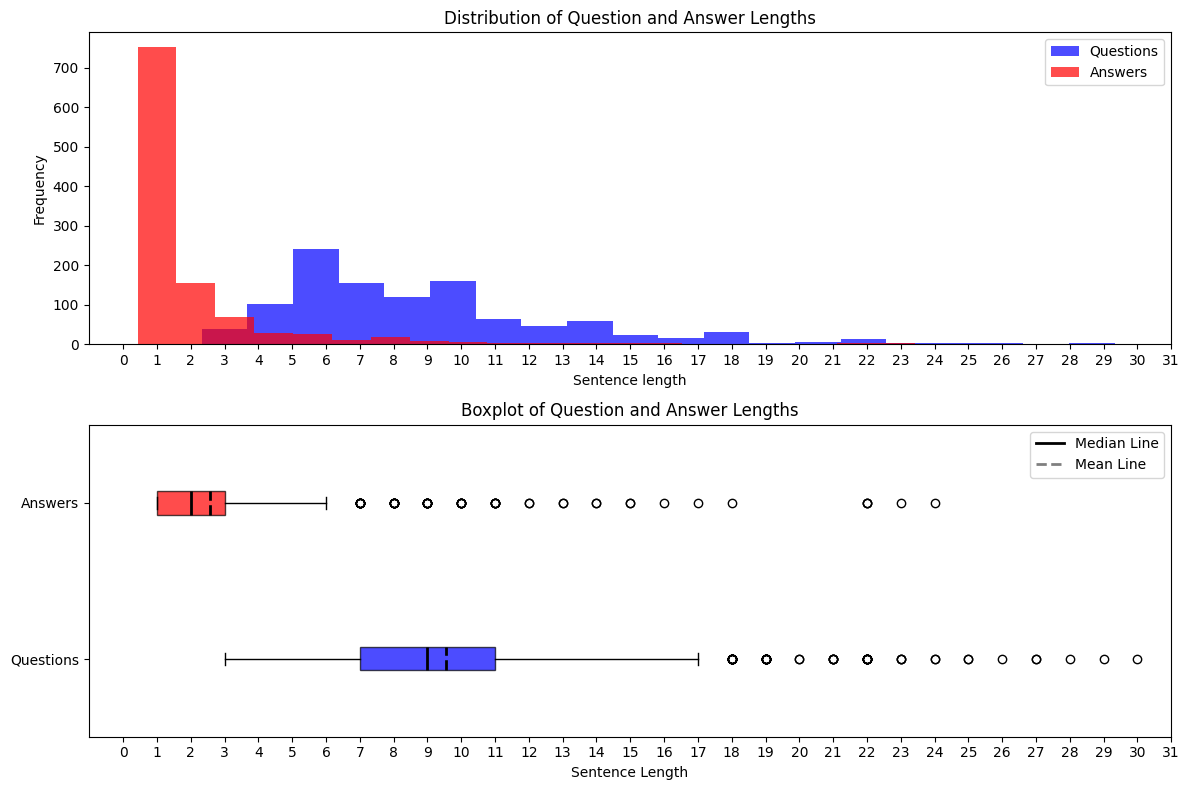

In [17]:
# let's plot the distribution of lengths of questions and answers

# A 1x2 grid of plots
fig, axs = plt.subplots(2,1,figsize=(12, 8))

# PLOT 1: Plot a histogram of the distribution of question lengths
axs[0].hist(question_lengths, bins=20, color='blue', alpha=0.7,align='left')
# Plot the distribution of answer lengths
axs[0].hist(answer_lengths, bins=20, color='red', alpha=0.7,align='left')
# Formatting
axs[0].set_title("Distribution of Question and Answer Lengths")
axs[0].set_xlabel("Sentence length")
axs[0].set_ylabel("Frequency")
axs[0].legend(["Questions", "Answers"])

# PLOT 2: Boxplot for question and answer lengths
box = axs[1].boxplot([question_lengths, answer_lengths], vert=False, patch_artist=True,
               tick_labels=["Questions", "Answers"],
               boxprops=dict(color="black"),  # Box border color
               medianprops=dict(color="black", linewidth=2),  # Median line in black
               meanline=True, showmeans=True, meanprops=dict(color="black", linewidth=2)
               )
# Fill colors for boxes
colors = ["blue", "red"]
for patch, color in zip(box["boxes"], colors):
    patch.set(facecolor=color, alpha=0.7)  # Set fill color
axs[1].set_title("Boxplot of Question and Answer Lengths")
axs[1].set_xlabel("Sentence Length")
# Create legend handles
legend_elements = [
    Line2D([0], [0], color="black", linewidth=2, label="Median Line"),
    Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Mean Line", alpha=0.5)
]
# Add legend to boxplot
axs[1].legend(handles=legend_elements, loc="upper right")

# Ensure both plots have the same x-axis range
axs[1].set_xlim(axs[0].get_xlim())
# Set x-axis ticks to go up in unit steps
axs[0].set_xticks(range(int(min(question_lengths & answer_lengths)), int(max(question_lengths | answer_lengths)) + 1))
axs[1].set_xticks(range(int(min(question_lengths & answer_lengths)), int(max(question_lengths | answer_lengths)) + 1))

plt.tight_layout()
plt.show()

From the plot above:
- Both questions and answers have longer sentences as outliers, perhaps they can be made more concise / clearer?
- The questions looks like a right-skewed normal distribution
- Most questions are ~17 words or less (75% percentile)
- Most questions fall between 7 and 11 words (inter-quartile range)
- The answers is also a very right-skewed distribution with a rapid decay.
- Most answers are ~6 words or less (75% percentile)
- One word answers are the most common. 


### Answer lengths
Let's start by taking a closer look at the word count frequencies of the answers.

In [18]:
# Frequency of answers based on word count
answers_wordcount = answer_lengths.value_counts()

# total word count:
total_word_count = answers_wordcount.sum()

# Percentage of word counts with 1-3 words, 4-11 words, and 12+ words:
percentage_4to11_wc = (answers_wordcount.loc[(answers_wordcount < 154) & (answers_wordcount >= 6) ].sum() / total_word_count) * 100
percentage_12plus_wc = (answers_wordcount.loc[answers_wordcount < 6].sum() / total_word_count) * 100
percentage_1to3_wc = (answers_wordcount.loc[answers_wordcount >= 154].sum() / total_word_count) * 100

# Display the results:
print(f'Total word count: {total_word_count}')
# Sum the frequency of all answer lengths that have more than 3 words, ie. count less then 154.
print(f'\nThe number of answers with a word count more than 3: {answers_wordcount.loc[answers_wordcount < 154 ].sum()}')
print(f'\nPercentage of answers with word count between 1 and 3: {percentage_1to3_wc:.2f}%')
print(f'\nPercentage of answers with word count between 4 and 11: {percentage_4to11_wc:.2f}%')
print(f'\nPercentage of answers with word count 12 or more: {percentage_12plus_wc:.2f}%')
print(f'\nWord count occurence in answers:\n\n{answers_wordcount}')

Total word count: 1085

The number of answers with a word count more than 3: 179

Percentage of answers with word count between 1 and 3: 83.50%

Percentage of answers with word count between 4 and 11: 15.02%

Percentage of answers with word count 12 or more: 1.47%

Word count occurence in answers:

answer
1     381
2     371
3     154
4      69
5      28
6      25
7      10
8       9
9       9
10      7
11      6
22      3
14      2
13      2
12      2
15      2
23      1
17      1
16      1
18      1
24      1
Name: count, dtype: int64


We can note that:
1. Majority of the answers are 1 to 3 words (75% percentile, 84% frequency count)
2. The remaining answers mostly fall within 4 to 11 word counts (15% frequency count) with the rest with 12 or more words occuring only ~1%.

Let's take a closer look at answers with 3 or less words, especially when only 1.

##### Short answers:

In [19]:
# Filter short answers
short_answers = trivia_df[answer_lengths < 4]

# filter by word_counts
answer_n_wc = {n: trivia_df[answer_lengths == n] for n in [1, 2, 3]}

# Number of unique words for each word count occurence:
unique_answers = {n: answer_n_wc[n]['answer'].nunique() for n in range(1, 4)}

# Extract frequency occurence for answers with 1,2, and 3 words explicitly
total_by_wc = answers_wordcount.loc[[1,2,3]]

# Display results
print(f"There are {short_answers.shape[0]} answers with one to three words and of those {total_by_wc.loc[1]} are one-word anwers\n")
# Number or unique words for one, two, and three word:
for i in range(1, 4):
    print(f"The number of unique {i}-word answers: {unique_answers[i]}, ({(unique_answers[i] / total_by_wc.loc[i]) * 100 :.0f}% of {i} word answers)")

# Display value counts of the one-word answers
print(f"\nOne word answers value counts:")
answer_n_wc[1]['answer'].value_counts()

There are 906 answers with one to three words and of those 381 are one-word anwers

The number of unique 1-word answers: 320, (84% of 1 word answers)
The number of unique 2-word answers: 313, (84% of 2 word answers)
The number of unique 3-word answers: 143, (93% of 3 word answers)

One word answers value counts:


answer
Fluffy             4
Transfiguration    4
Hogsmeade          3
Norbert            3
Ravenclaw          3
                  ..
Horcrux            1
Charm              1
Slugs              1
Antarctica         1
Antidotes          1
Name: count, Length: 320, dtype: int64

We can see that most of the short-word answers are unique and there is considerable variety in the answers.

##### Long answers

In [20]:
# display the full content of all columns without truncation
pd.set_option('display.max_colwidth', None)

# Filter and display the long answers (greater than the 75% percentile range)
wc_threshold = 6
long_answers= trivia_df[answer_lengths > wc_threshold]

# Display results
print(f"There are {long_answers['answer'].count()} answers with a word count greater than {wc_threshold}\n\n")
print(long_answers['answer'])

There are 57 answers with a word count greater than 6


8                                                                                                                                                  Bill, Charlie, Percy, Fred, George, Ron, and Ginny.
41                                                                                                                                                               A doe (the same as Lily Potter’s—sob)
48                                                                                                                                 Filius Flitwick remains the Charms professor throughout the series.
81                                                                                                                                  His aunt and uncle, Petunia and Vernon Dursley, and cousin Dudley.
119                                                                                                                                      She is wait

**Notes**:
- Some of the longest (including the most long) answers are lists.
- A few answers are just wordy.
- Others need to be long to give the full answer.

In [21]:
# Let's look at long answer outliers:
long_answers= trivia_df[answer_lengths >= 17]

# Display the number of unique words in the one-word answers and total number of one-word answers
print(f"The number of outlier long answers: {long_answers.shape[0]}\n",
      f"\n The outlier long answers are:\n\n{long_answers['answer']}")

The number of outlier long answers: 7
 
 The outlier long answers are:

346                                                                                      38. It was 36 (one less than last year), but then Mrs. Dursley bought him two new presents to make up for it.
545                                                                      “Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much.”
655                                                                                                  He uses the Patronus Charm in front of a Muggle (Dudley, and only because there were Dementors!).
715                                                                       In the book, the mummy trips on its wrappings. In the movie, it turns into a giant jack-in-the-box (arguably no less scary).
827                                                        Lacewing flies, leeches, powdered Bicorn horn, knotgrass, fluxweed, shred

### Questions lengths

>📝  **Notes**:
>1. Majority of the answers are short words (75% of words are 3 words or less). This would make checking answers for these questions relatively straight forward.
>2. There are 179 answers that are longer then 3 word. A lot of them can be shortened to fewer ones. Can write a script with NER to update these later on to have a cleaner dataset.
>3. There are 7 outlier questions, some of which can be simpliefied.
>4. The questions are
> 
> Overall we can consider the quality of the questions and answer to be good with a good sized dataset for the the trivia game and a nice variety in those questions. It will be interesting to see what the difficulty of those questions are like.
> <br>


### Question and answer correlation

## Add keywords and categories columns

We can augment this list using a tokenizer.

In [22]:
# create a copy of trivia_df
keywords_df = trivia_df.copy()

lemmatizer = WordNetLemmatizer()
ENGLISH_STOP_WORDS = set(stopwords.words('english'))

# Function to convert POS tags for better lemmatization
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

# Custom tokenizer with lemmatization
def tokenize_text(text):
    '''
    Takes a sentence:
    - Removes punctuation
    - Converts to lowercase
    - Tokenizes into words
    - Removes stopwords
    - Lemmatizes each word based on POS tagging
    
    Returns list of lemmatized tokens.
    '''
    
    # Keep only letters and spaces, removing numbers and punctuatio
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stopwords and single letter words before POS tagging for efficiency
    filtered_tokens = [word for word in tokens if (word not in ENGLISH_STOP_WORDS) and (len(word) > 1)]

    # POS tagging
    pos_tags = pos_tag(filtered_tokens)

    # Lemmatize each word
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

    return lemmatized_words

# Create unique 'keywords' column by tokenizing 'question' and 'answer', excluding unwanted words
keywords_df['question keywords'] = keywords_df.apply(lambda row: list(set(OrderedDict.fromkeys(tokenize_text(row['question'])))), axis=1)
keywords_df['answer keywords'] = keywords_df.apply(lambda row: list(set(OrderedDict.fromkeys(tokenize_text(row['answer'])))), axis=1)
keywords_df['combined keywords'] = keywords_df.apply(lambda row: row['question keywords']+ row['answer keywords'])
# Display the updated DataFrame
keywords_df.head()

KeyError: 'question keywords'

In [ ]:
# Extract unique tokens for each row in the 'keywords' column
df['unique_keywords'] = df['keywords'].apply(lambda x: list(set(x)))  # Already done in tokenization
df.drop(columns=['keywords'], inplace=True)  # Drop the original 'keywords' column

# Flatten the list of all tokens to count their occurrences across the DataFrame
all_keywords = [token for sublist in df['unique_keywords'] for token in sublist]

# Count the frequency of each token across all rows
token_counts = Counter(all_keywords)

# Display the DataFrame and the token counts
token_counts

Counter({'harry': 123,
         'name': 117,
         'hogwarts': 89,
         'use': 66,
         'spell': 63,
         'potion': 63,
         'potter': 60,
         'charm': 51,
         'first': 50,
         'magical': 46,
         'quidditch': 46,
         'creature': 45,
         'professor': 45,
         'book': 40,
         'hermione': 36,
         'ron': 34,
         'magic': 34,
         'many': 33,
         'one': 32,
         'wizard': 30,
         'weasley': 29,
         'know': 28,
         'make': 28,
         'follow': 28,
         'house': 27,
         'year': 26,
         'transfiguration': 25,
         'student': 24,
         'object': 24,
         'dumbledore': 23,
         'whats': 23,
         'dragon': 22,
         'plant': 22,
         'harrys': 21,
         'would': 21,
         'type': 20,
         'incantation': 20,
         'snape': 19,
         'ministry': 19,
         'take': 18,
         'ingredient': 18,
         'get': 18,
         'gryffindor': 18,
    

---

## Data checkpoint 2: 
Save clean dataset (nulls, duplicates removed) and new column with unique keywords

> **⚠️ Caution: Manual Intervention Required for Saving Files**
>
> Please be aware that the `save_dataframe_to_csv` utility is designed to prevent accidental data loss. It **does not automatically overwrite** previously saved files.
>
> If you run a cell that calls this function and the output file (based on `filename_base`, `version`, and `subfolder`) already exists, the save operation will be skipped. You will see a message indicating this.
>
> **To save your latest data, you must manually intervene by either:**
> 1.  Deleting the older version of the CSV file from the file system.
> 2.  Modifying the `version` argument (or `filename_base`) in your function call to create a new, unique filename.

In [ ]:
# Save the cleaned csv file to the data folder using custom function from utils.paths.py
# It saves the file or returns a message that the file already exists and save is skipped.

# Save arguments
dataframe_to_save = df
name_for_csvfile = 'clean_trivia_dataset_withKeywords'
csv_version = 'v0'
csv_subfolder = 'project_datasets'

# Save csv  file with custom functions and defined save arguments
up.save_dataframe_to_csv(dataframe_to_save, name_for_csvfile, csv_version, csv_subfolder)

DataFrame saved successfully to: data/project_datasets/clean_trivia_dataset_withKeywords_v0.csv


PosixPath('/Users/reemasipra/Documents/GitHub_Repos/Harry_Potter_Trivia/data/project_datasets/clean_trivia_dataset_withKeywords_v0.csv')

---

In [ ]:
# Sort token_counts by token (alphabetically)
sorted_token_counts = dict(sorted(token_counts.items(), key=lambda item: item[1], reverse=True))

# Convert the token counts to a DataFrame
token_df = pd.DataFrame(sorted_token_counts.items(), columns=['token', 'count'])

token_df

,token,count
0,harry,123
1,name,117
2,hogwarts,89
3,use,66
4,spell,63
...,...,...
2431,pertain,1
2432,third,1
2433,enjoy,1
2434,retiring,1


In [ ]:
# Filter the DataFrame to include only rows where count is greater than 30
filtered_df = token_df[token_df['count'] > 20]
filtered_df.head()

,token,count
0,harry,123
1,name,117
2,hogwarts,89
3,use,66
4,spell,63


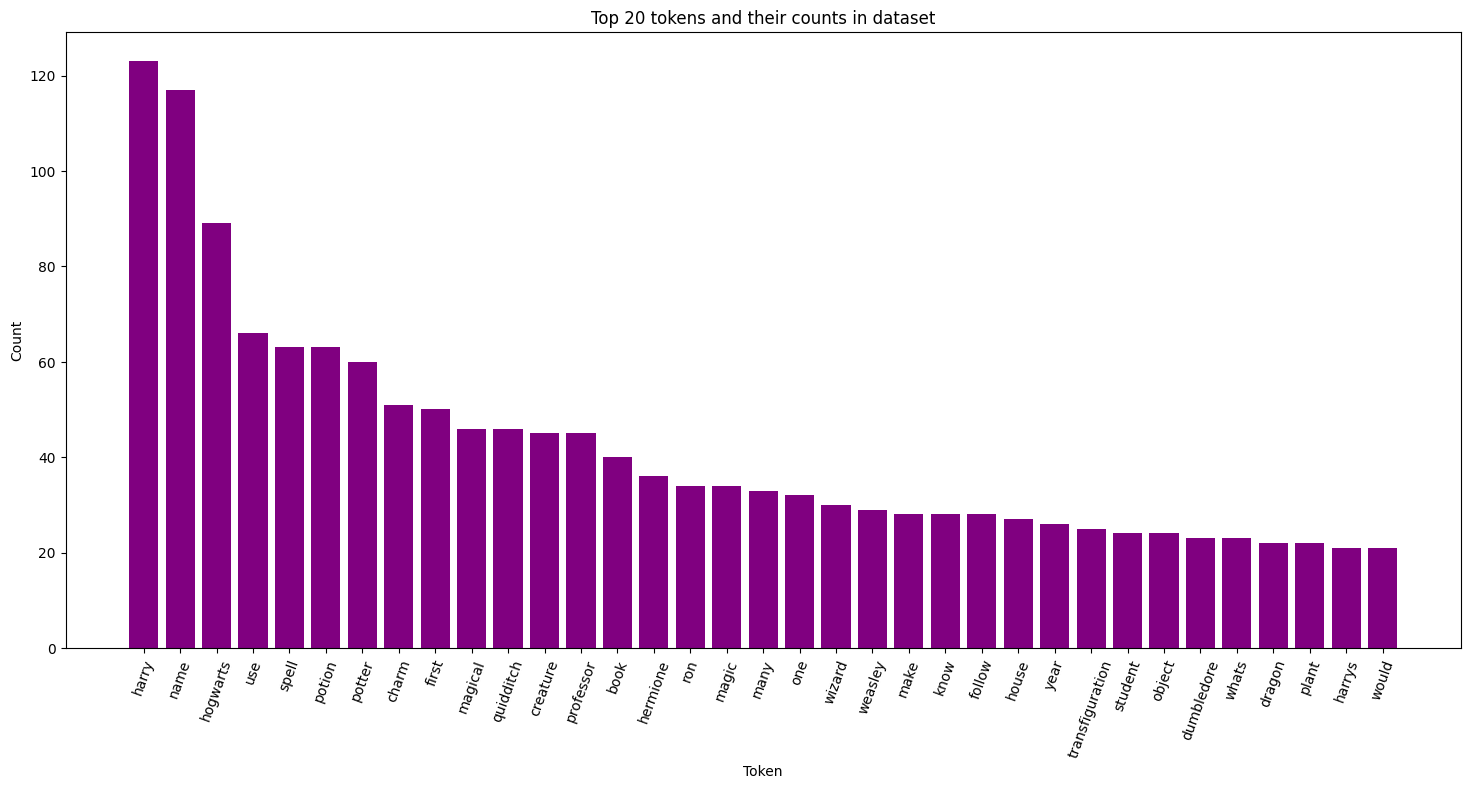

In [ ]:
plt.figure(figsize=(18,8))

plt.bar(filtered_df['token'], filtered_df['count'], color="purple")

plt.xlabel('Token')
plt.ylabel('Count')
plt.title("Top 20 tokens and their counts in dataset")
plt.xticks(rotation=70)
plt.show()

lets look at the rows that have "name" as a keyword.


In [ ]:
# Filter the rows where 'keywords' column contains the word 'name'
df_filtered = df[df['unique_keywords'].apply(lambda x: 'name' in x)]

# Display the filtered DataFrame
df_filtered.sample(10)

,question,answer,unique_keywords
1187,What is the full name of Nearly Headless Nick?,Sir Nicholas de Mimsy-Porpington,"[full, sir, nick, nicholas, nearly, headless, de, name, mimsyporpington]"
8,Name all seven Weasley children.,"Bill, Charlie, Percy, Fred, George, Ron, and Ginny.","[percy, weasley, seven, charlie, ron, ginny, george, name, fred, bill, child]"
259,"What is the middle name of Harry's daughter, Lily?",Luna,"[middle, lily, luna, daughter, name, harrys]"
643,What is the name of the Hogwarts caretaker who is always complaining about the students?,Argus Filch,"[student, complain, name, always, filch, caretaker, hogwarts, argus]"
320,What is the name of Fleur Delacour and Bill Weasley’s house?,Shell Cottage,"[house, delacour, shell, name, bill, weasleys, cottage, fleur]"
1233,"What is the name of the popular, sweet drink usually served in Hogsmeade?",Butterbeer.,"[sweet, usually, serve, hogsmeade, name, popular, drink, butterbeer]"
447,What is the name of the three-headed dog guarding the trapdoor in Harry Potter and the Sorcerer's Stone?,Fluffy,"[dog, trapdoor, potter, threeheaded, guard, harry, sorcerer, name, stone, fluffy]"
342,What is the name of Harry's owl?,Hedwig,"[hedwig, name, owl, harrys]"
3,You wouldn't know anything about this. Name a method to make your broom go faster.,Using polish,"[method, wouldnt, anything, make, polish, go, use, name, know, broom, faster]"
287,What is the name of the powerful and dangerous artifact that Voldemort creates in the Harry Potter series by splitting his soul into seven pieces?,The Horcruxes,"[dangerous, voldemort, potter, split, soul, harry, seven, powerful, artifact, create, name, series, piece, horcruxes]"
